In [ ]:
import pandas as pd
import itables as it
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import re
import unicodedata
from IPython.display import IFrame
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

it.init_notebook_mode(all_interactive=True)

In [7]:
data = pd.read_excel('who_aap_2021_v9_11august2022.xlsx', sheet_name='AAP_2022_city_v9')
data

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [8]:
#braki danych
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Braki (ilość)': missing_data, 'Braki (%)': missing_percent})
missing_df

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [9]:
data.drop(columns=['Status'], inplace=True)

In [10]:
#informacje o danych dla zanieczyszczeń
pollutants = ['PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']
display(data[pollutants].describe())

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


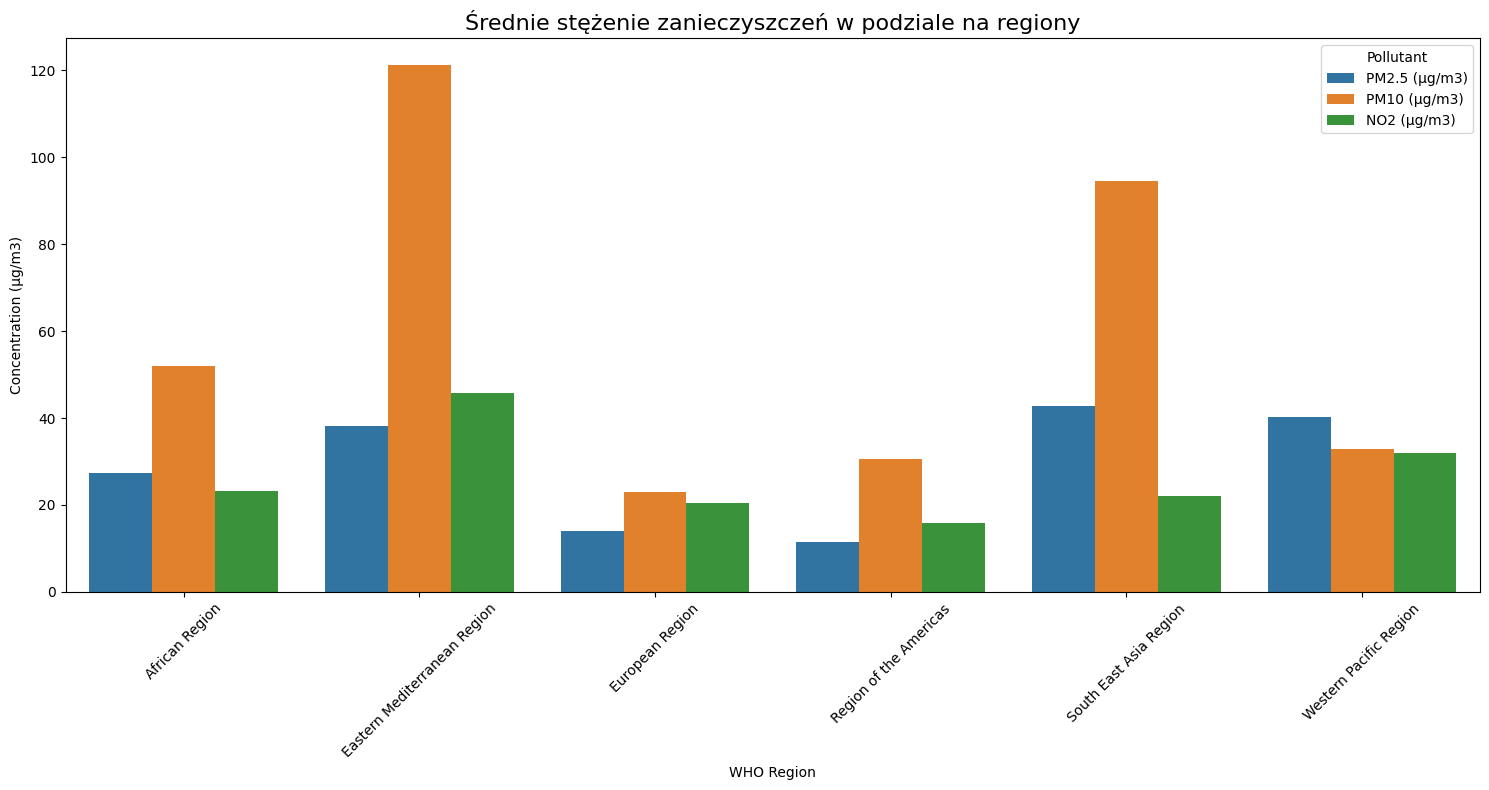

In [11]:
#generalizacja na poziomie regionów umożliwia porównanie średnich dla całych regionów
region_mean = data.groupby('WHO Region')[pollutants].mean().reset_index()

region_mean_melted = region_mean.melt(id_vars='WHO Region', var_name='Pollutant', value_name='Concentration (μg/m3)')

plt.figure(figsize=(15, 8))
sns.barplot(data=region_mean_melted, x='WHO Region', y='Concentration (μg/m3)', hue='Pollutant')
plt.title('Średnie stężenie zanieczyszczeń w podziale na regiony', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

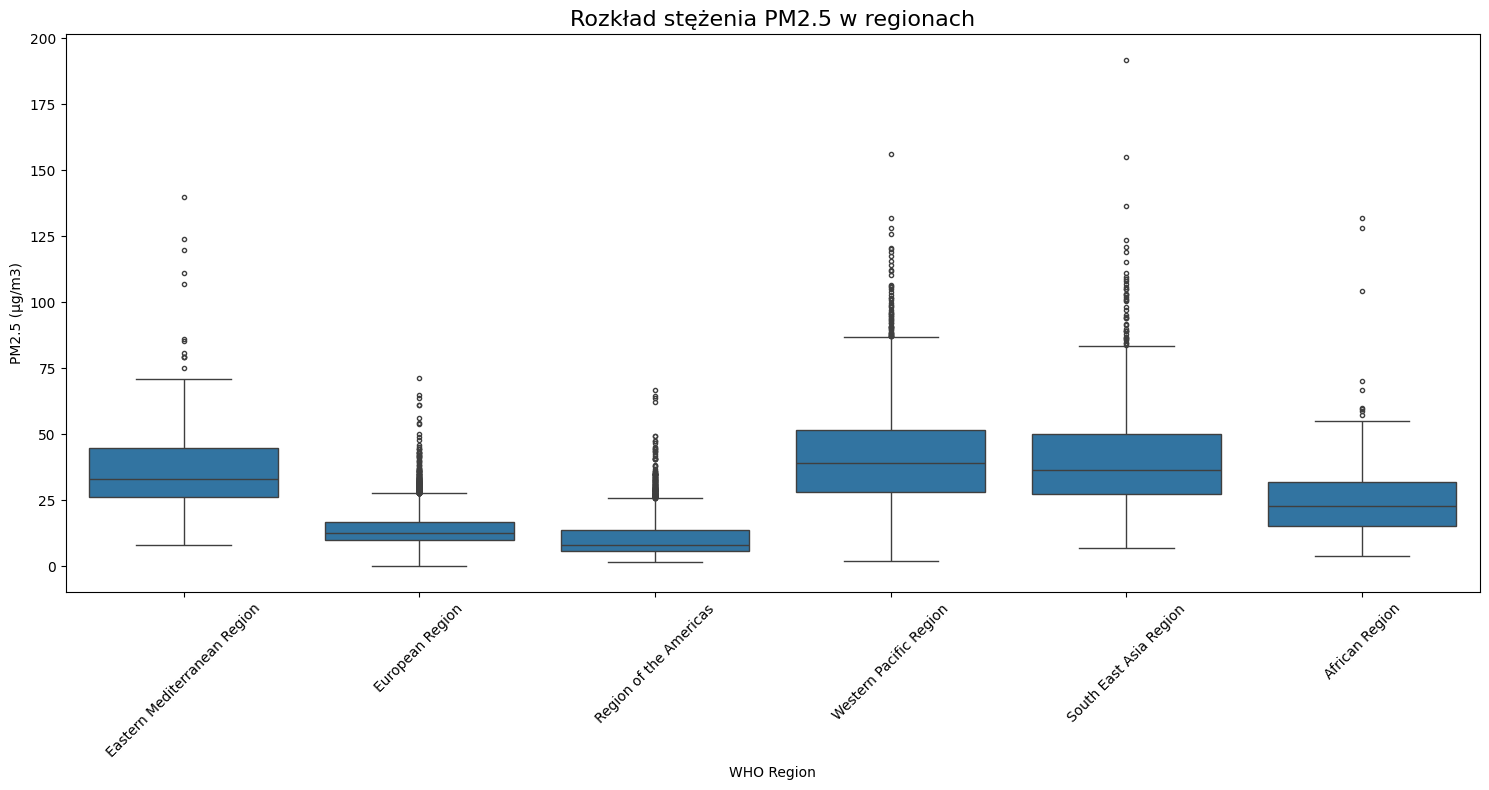

In [12]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=data, x='WHO Region', y='PM2.5 (μg/m3)', fliersize=3)
plt.title('Rozkład stężenia PM2.5 w regionach', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('PM2.5 (μg/m3)')
plt.tight_layout()
plt.show()

C:\Users\kubek\AppData\Local\Temp\ipykernel_29092\518478443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


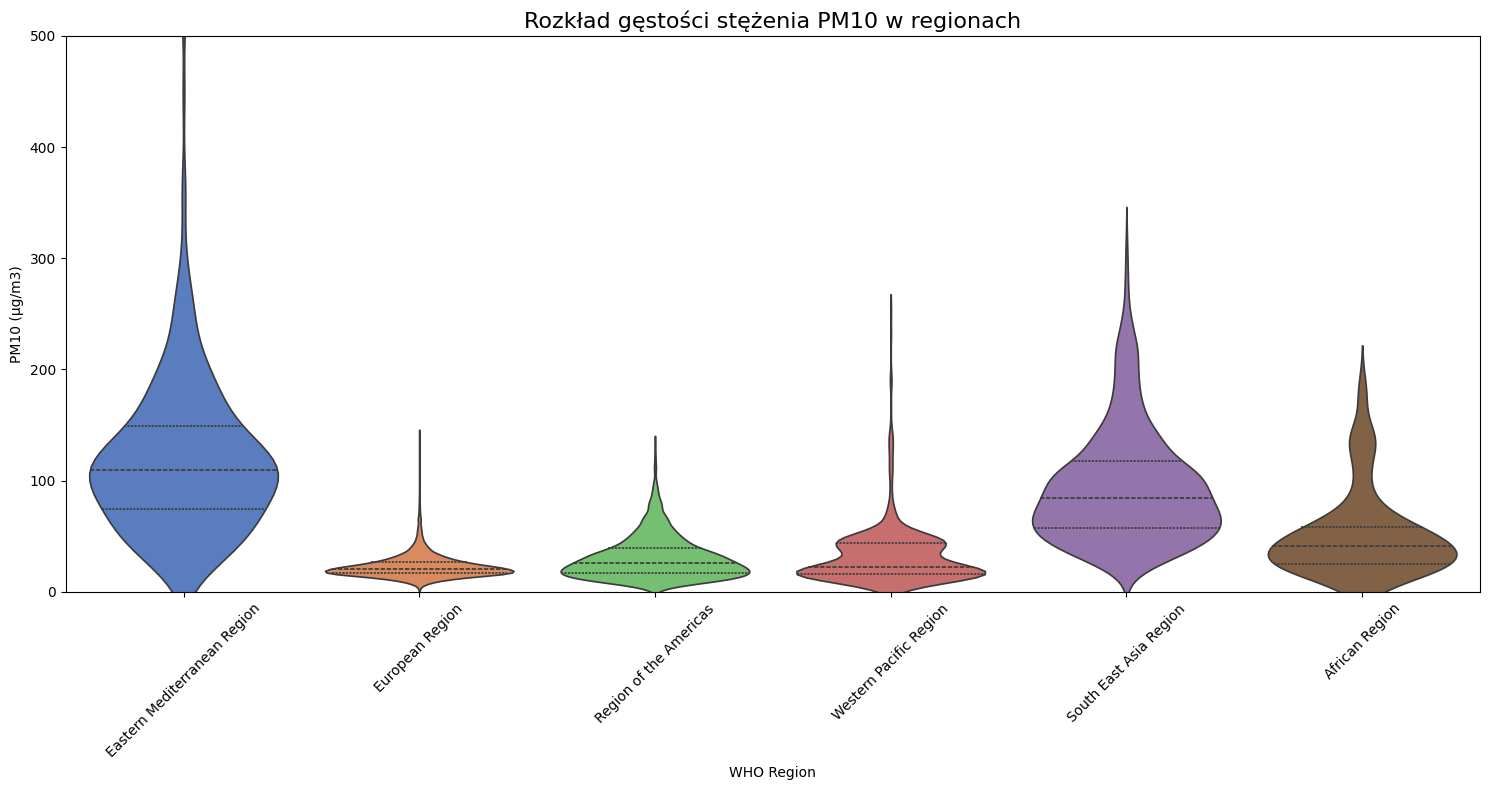

In [13]:
plt.figure(figsize=(15, 8))
sns.violinplot(
    data=data, 
    x='WHO Region', 
    y='PM10 (μg/m3)', 
    palette='muted', 
    inner='quartile',
)
plt.title('Rozkład gęstości stężenia PM10 w regionach', fontsize=16)
plt.xticks(rotation=45)

plt.ylim(0, 500) 
plt.tight_layout()
plt.show()

C:\Users\kubek\AppData\Local\Temp\ipykernel_29092\1777716891.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_pm25.values, y=country_pm25.index, palette='Reds_r')


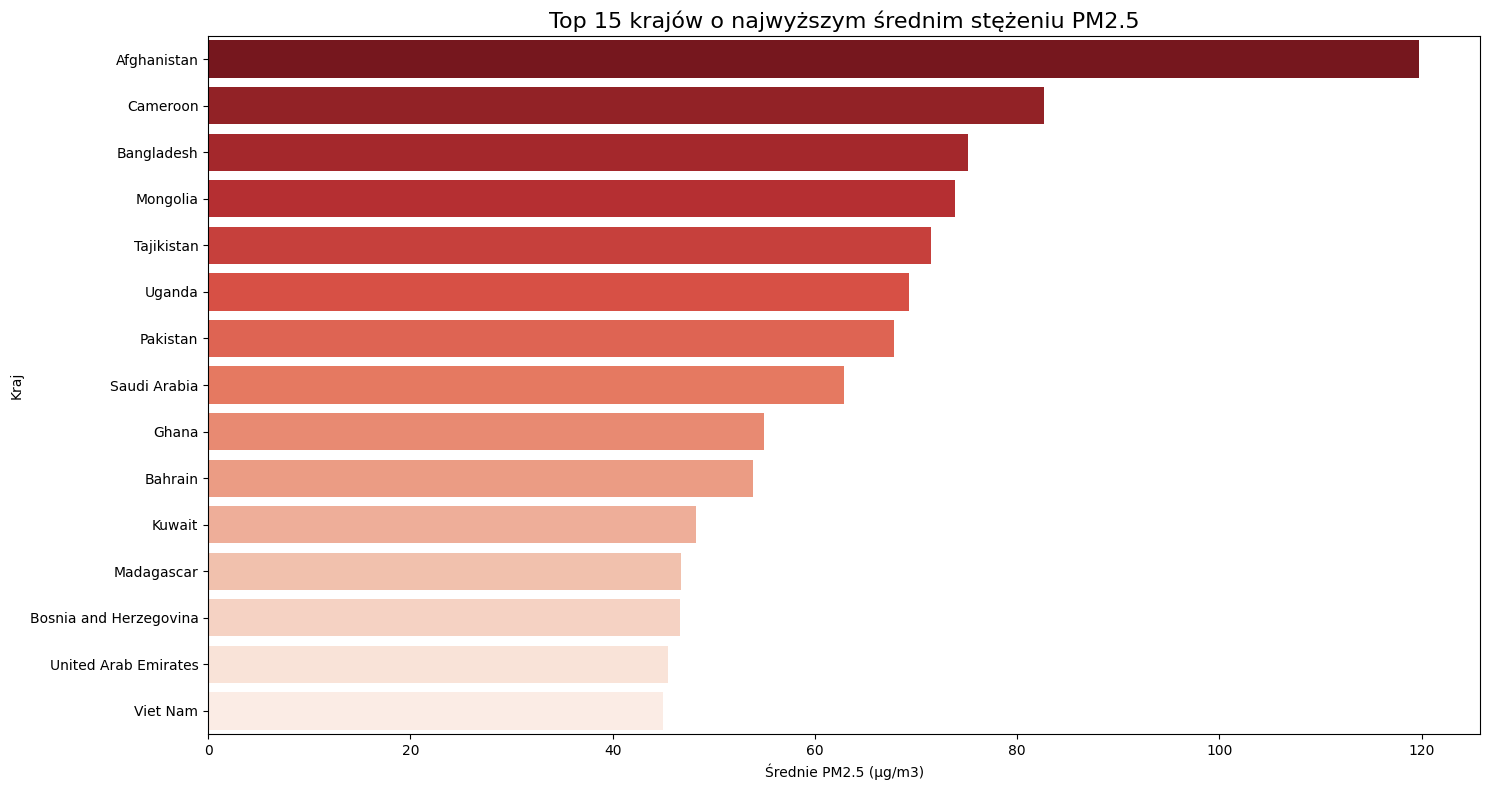

In [14]:
#Generalizacja na poziomie krajów nie pozwala na porównanie ich wszystkich ze względu na ich ilość, więc ograniczamy się do np. prezentacji 15 krajów o najwyższym stężeniu pm2.5
country_pm25 = data.groupby('WHO Country Name')['PM2.5 (μg/m3)'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(15, 8))
sns.barplot(x=country_pm25.values, y=country_pm25.index, palette='Reds_r')
plt.title('Top 15 krajów o najwyższym średnim stężeniu PM2.5', fontsize=16)
plt.xlabel('Średnie PM2.5 (μg/m3)')
plt.ylabel('Kraj')
plt.tight_layout()
plt.show()

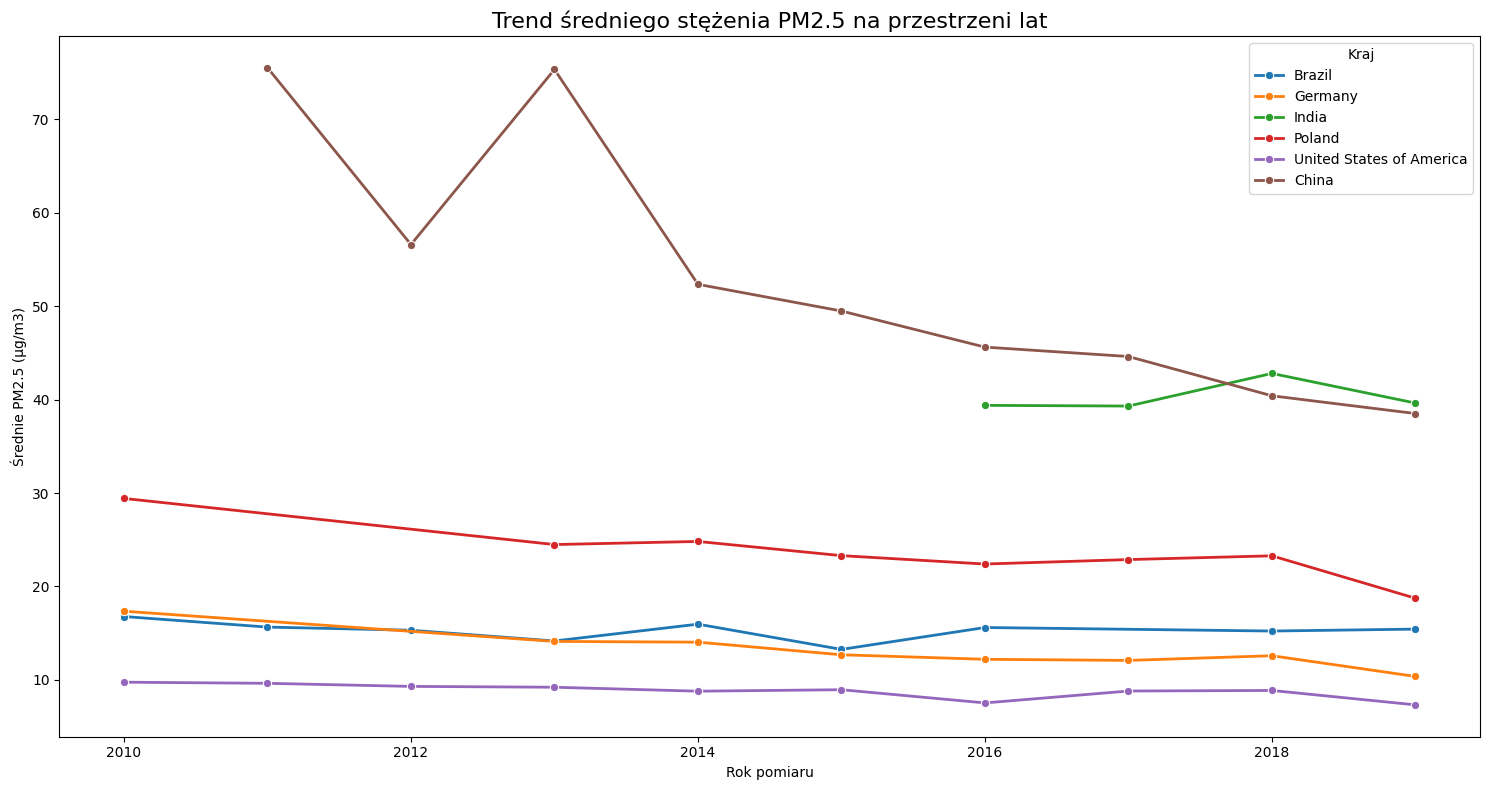

In [15]:
#możemy porównać trendy dla krajów, jednak ten poziom generalizacji może utrudniać szczegółową analizę (porównywanie średniej z całego USA do śrendiej z np Polskii nie jest idealnym rozwiązaniem)
countries_to_plot = ['Poland', 'India', 'Germany', 'China','United States of America','Brazil']
trend_data = data[data['WHO Country Name'].isin(countries_to_plot)]
trend_grouped = trend_data.groupby(['Measurement Year', 'WHO Country Name'])['PM2.5 (μg/m3)'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.lineplot(data=trend_grouped, x='Measurement Year', y='PM2.5 (μg/m3)', hue='WHO Country Name', marker='o', linewidth=2)
plt.title('Trend średniego stężenia PM2.5 na przestrzeni lat', fontsize=16)
plt.ylabel('Średnie PM2.5 (μg/m3)')
plt.xlabel('Rok pomiaru')
plt.legend(title='Kraj')
plt.tight_layout()
plt.show()

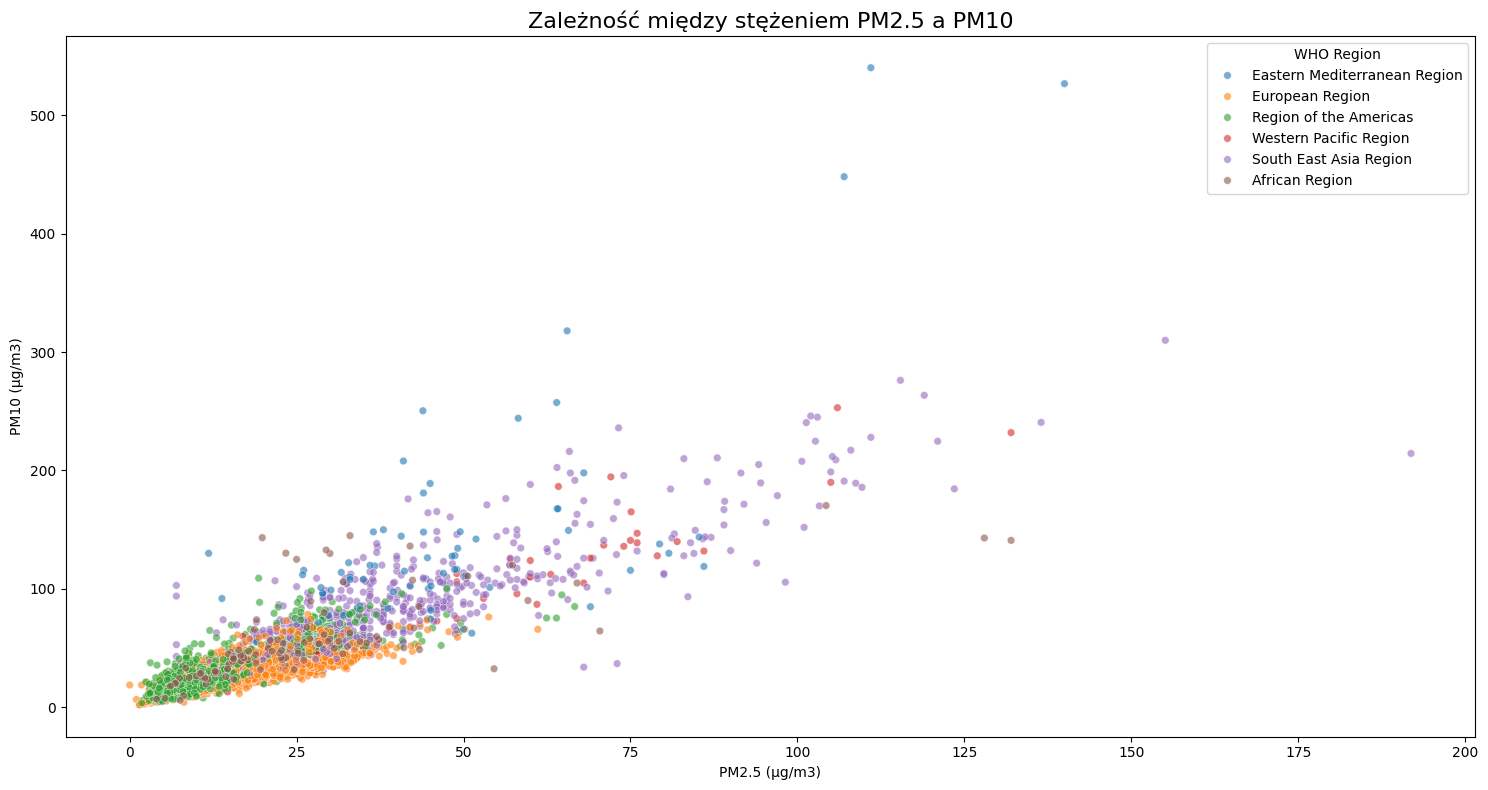

In [16]:
#Poziom generalizacji na miastach - bardzo duża ilość miast utrudnia analizę, jednak ze względu na ograniczenie do konkretnego małego obszaru można pozyskać bardziej miarodajne i szczegółowe informacje
plt.figure(figsize=(15, 8))
sns.scatterplot(
    data=data, 
    x='PM2.5 (μg/m3)', 
    y='PM10 (μg/m3)', 
    hue='WHO Region', 
    alpha=0.6, 
    s=30 
)

plt.title('Zależność między stężeniem PM2.5 a PM10', fontsize=16)
plt.tight_layout()
plt.show()

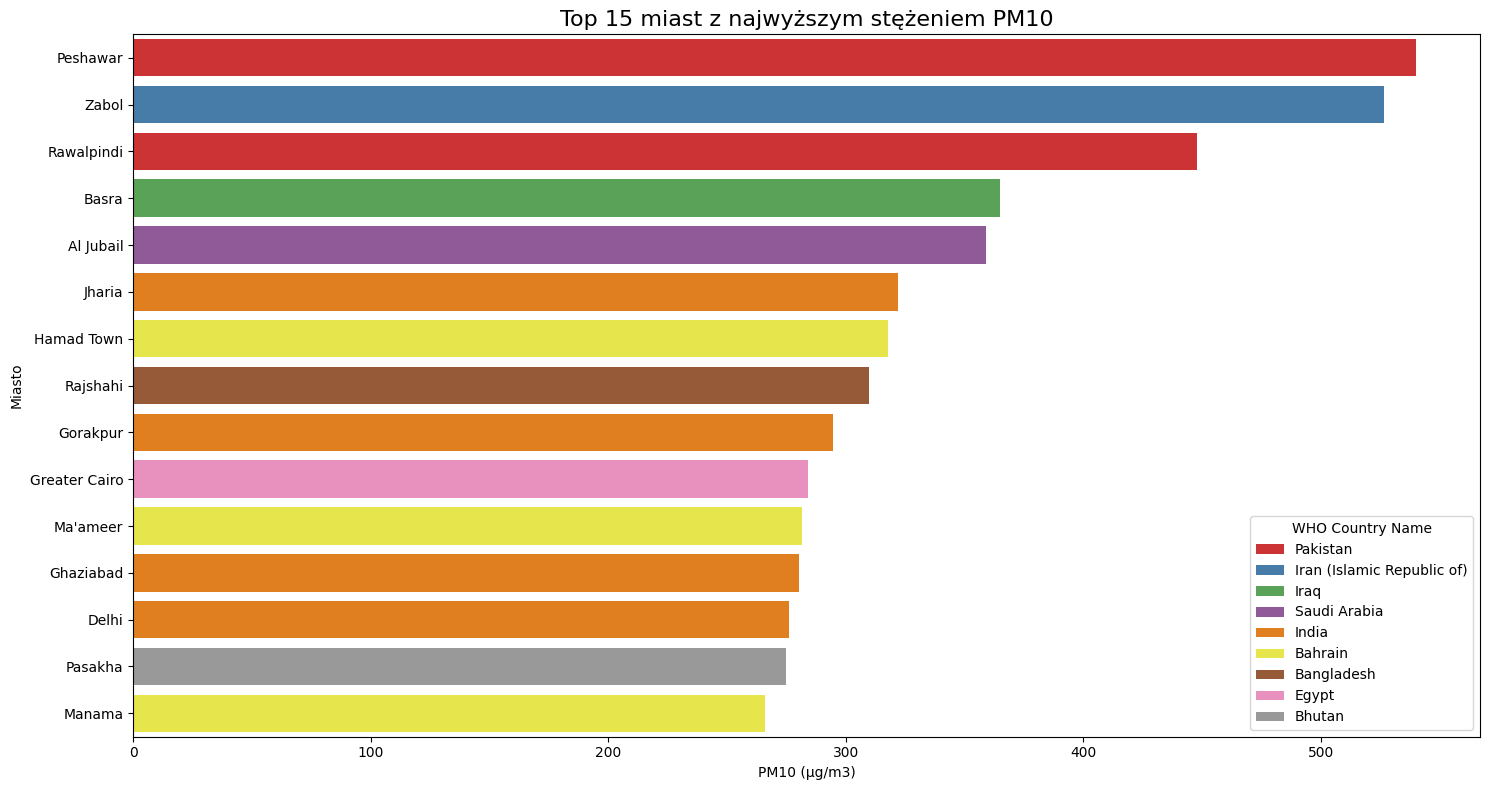

In [17]:
city_pm10 = data.groupby(['WHO Country Name', 'City or Locality'])['PM10 (μg/m3)'].max().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=city_pm10, x='PM10 (μg/m3)', y='City or Locality', hue='WHO Country Name', palette='Set1')
plt.title('Top 15 miast z najwyższym stężeniem PM10', fontsize=16)
plt.xlabel('PM10 (μg/m3)')
plt.ylabel('Miasto')
plt.tight_layout()
plt.show()


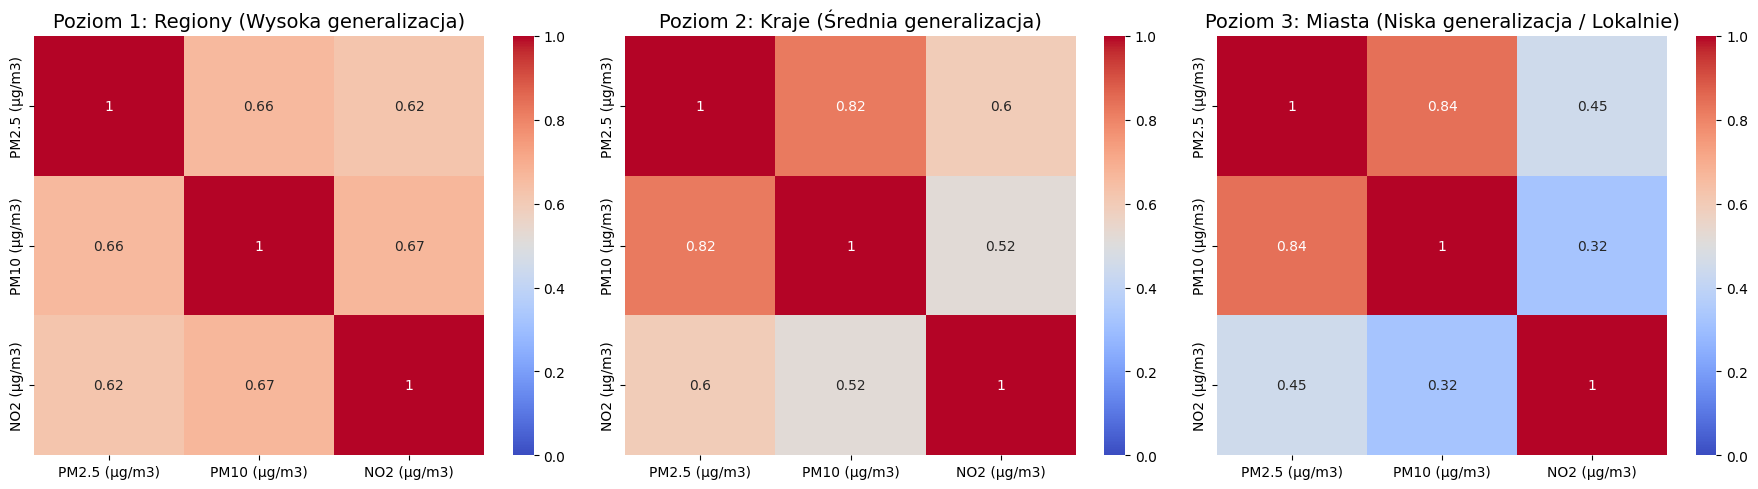

In [18]:
#wizualizacja korelacji na 3 poziomach generalizacji pokazuje jak przydatne mogą być dane ze względy na punkt z którego na nie patrzymy
pollutants = ['PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']

region_data = data.groupby('WHO Region')[pollutants].mean()
corr_region = region_data.corr()

country_data = data.groupby('WHO Country Name')[pollutants].mean()
corr_country = country_data.corr()

city_data = data.groupby([ 'City or Locality'])[pollutants].mean()
corr_city = city_data.corr()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
heatmap_kwargs = {'annot': True, 'cmap': 'coolwarm', 'vmin': 0, 'vmax': 1}

sns.heatmap(corr_region, ax=axes[0], **heatmap_kwargs)
axes[0].set_title('Poziom 1: Regiony (Wysoka generalizacja)', fontsize=14)
sns.heatmap(corr_country, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('Poziom 2: Kraje (Średnia generalizacja)', fontsize=14)
sns.heatmap(corr_city, ax=axes[2], **heatmap_kwargs)
axes[2].set_title('Poziom 3: Miasta (Niska generalizacja / Lokalnie)', fontsize=14)

plt.tight_layout()
plt.show()

In [107]:
#dekompozycja trendu na sezonowość jest raczej bezcelowa ze względy na brak podziału danych na miesiące, a jedynie na lata, co uniemożliwia analizę sezonowości w ciągu roku.

In [19]:
### INFORMACYJNIE POCZATEK PODPUNKTU 3


# Porównanie średnich i median dla poszczególnych regionów oraz krajów
# Mediana lepiej oddaje typowe miasta w regionie/kraju, ponieważ jest mniej podatna na wartości odstające
# Za pomocą ich porównania można ocenić rozkład danych i skośność oraz obecność wartości odstających.
# Różnica wartośc (nizsza mediana) wskazuje na występowanie miast o bardzo wysokim zanieczyszczeniu

region_stats = data.groupby('WHO Region')[pollutants].agg(['mean', 'median']).round(1)
region_stats.columns = ['_'.join(c) for c in region_stats.columns]

country_stats = data.groupby('WHO Country Name')[pollutants].agg(['mean', 'median']).round(1)
country_stats.columns = ['_'.join(c) for c in country_stats.columns]

print('Statystyki na poziomie REGIONU:')
display(region_stats)
print('Statystyki na poziomie KRAJU:')
display(country_stats)

Statystyki na poziomie REGIONU:


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Statystyki na poziomie KRAJU:


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


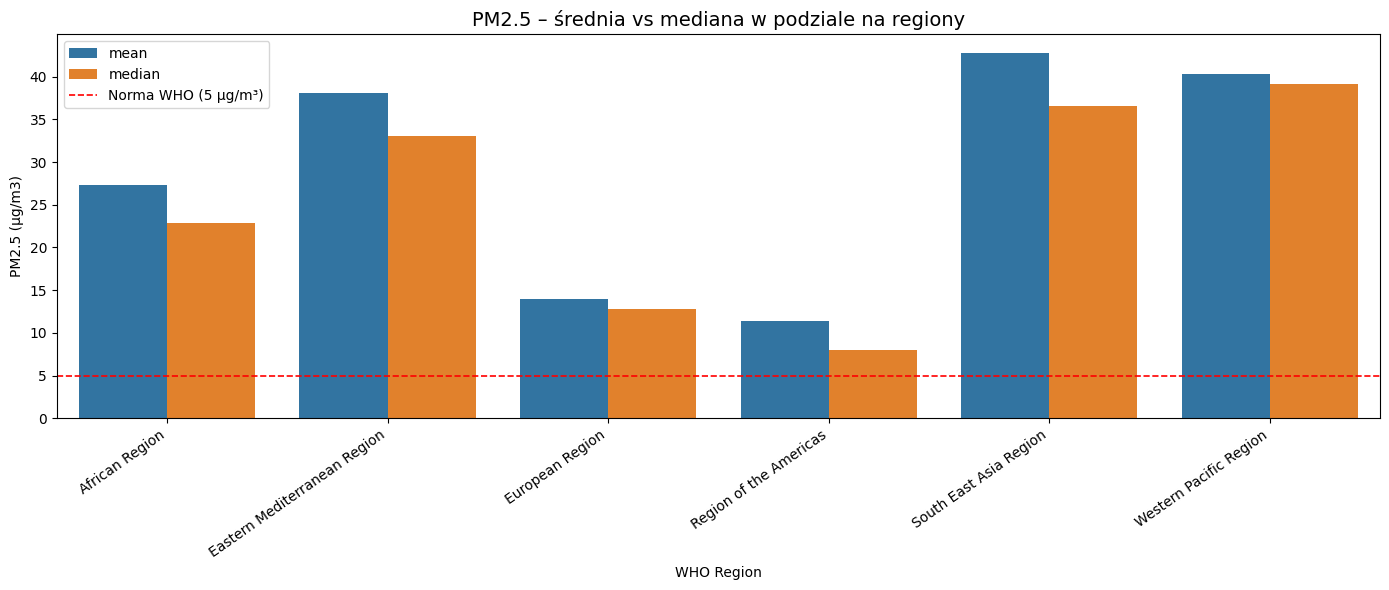

In [20]:
# Wizualizacja średnich i median dla poszczególnych regionów dla PM2.5
# Dla krajów jest to niemożliwe do wizualizacji w ten sposób ze względu na ilość

region_stats = data.groupby('WHO Region')['PM2.5 (μg/m3)'].agg(['mean', 'median']).round(1).reset_index()
region_stats_melted = region_stats.melt(id_vars='WHO Region', var_name='Statystyka', value_name='PM2.5 (μg/m3)')

plt.figure(figsize=(14, 6))
sns.barplot(data=region_stats_melted, x='WHO Region', y='PM2.5 (μg/m3)', hue='Statystyka')
plt.axhline(5, color='red', linestyle='--', linewidth=1.2, label='Norma WHO (5 μg/m³)')
plt.title('PM2.5 – średnia vs mediana w podziale na regiony', fontsize=14)
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

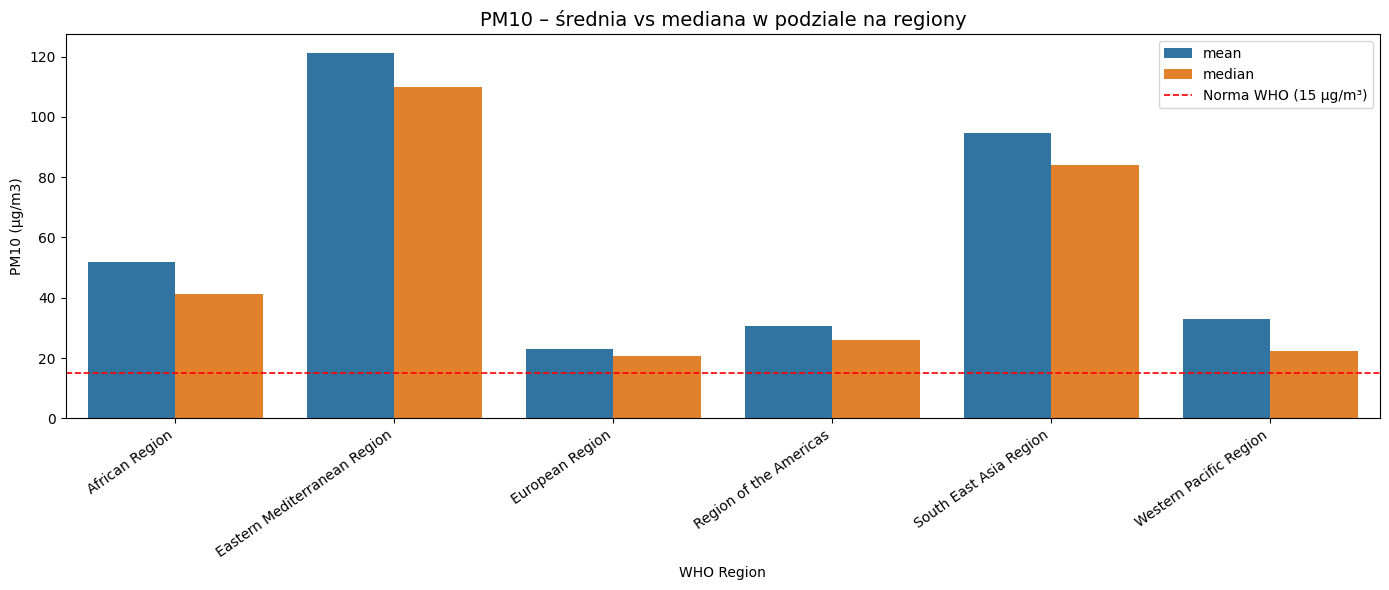

In [21]:
# Wizualizacja średnich i median dla poszczególnych regionów dla PM10

region_stats = data.groupby('WHO Region')['PM10 (μg/m3)'].agg(['mean', 'median']).round(1).reset_index()
region_stats_melted = region_stats.melt(id_vars='WHO Region', var_name='Statystyka', value_name='PM10 (μg/m3)')

plt.figure(figsize=(14, 6))
sns.barplot(data=region_stats_melted, x='WHO Region', y='PM10 (μg/m3)', hue='Statystyka')
plt.axhline(15, color='red', linestyle='--', linewidth=1.2, label='Norma WHO (15 μg/m³)')
plt.title('PM10 – średnia vs mediana w podziale na regiony', fontsize=14)
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

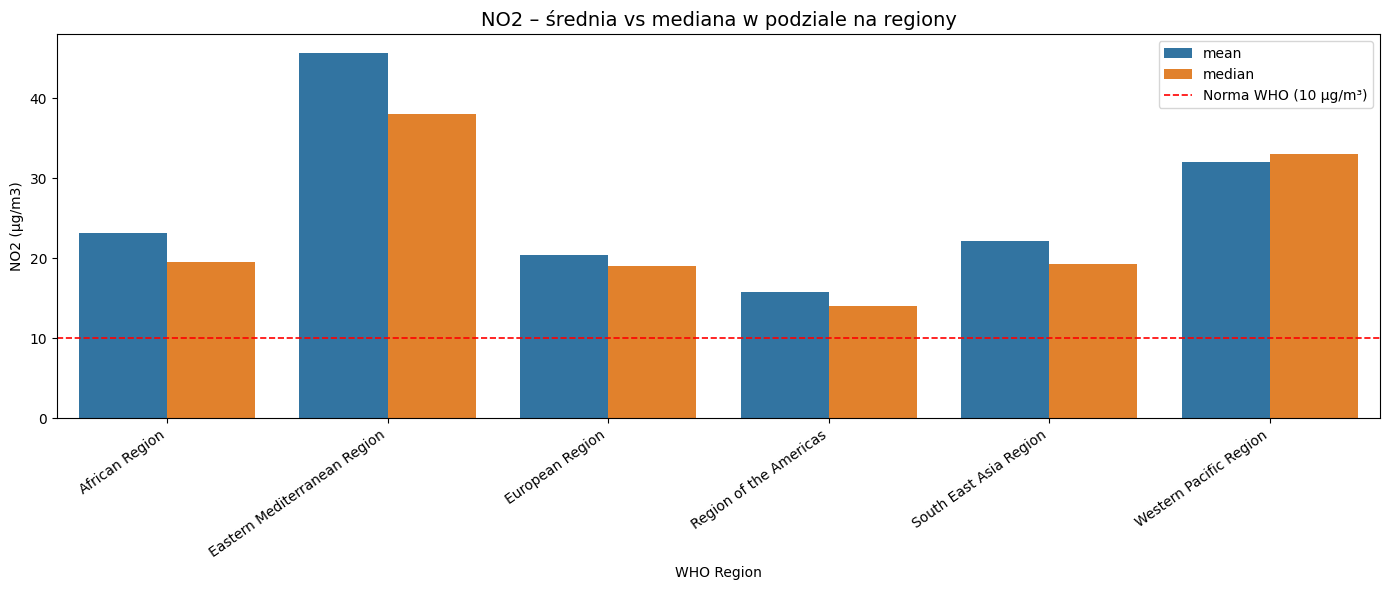

In [22]:
# Wizualizacja średnich i median dla poszczególnych regionów dla NO2

region_stats = data.groupby('WHO Region')['NO2 (μg/m3)'].agg(['mean', 'median']).round(1).reset_index()
region_stats_melted = region_stats.melt(id_vars='WHO Region', var_name='Statystyka', value_name='NO2 (μg/m3)')

plt.figure(figsize=(14, 6))
sns.barplot(data=region_stats_melted, x='WHO Region', y='NO2 (μg/m3)', hue='Statystyka')
plt.axhline(10, color='red', linestyle='--', linewidth=1.2, label='Norma WHO (10 μg/m³)')
plt.title('NO2 – średnia vs mediana w podziale na regiony', fontsize=14)
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Odsetek miast przekraczających normy WHO w każdym regionie.

WHO_LIMITS = {'PM2.5 (μg/m3)': 5, 'PM10 (μg/m3)': 15, 'NO2 (μg/m3)': 10}
 
exceed = {}
for region, grp in data.groupby('WHO Region'):
    exceed[region] = {p: (grp[p].dropna() > WHO_LIMITS[p]).mean() * 100 for p in pollutants}
 
exceed_df = pd.DataFrame(exceed).T.round(1)
it.show(exceed_df, classes="display", style="")

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


C:\Users\kubek\AppData\Local\Temp\ipykernel_29092\1586167577.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Reds_r')


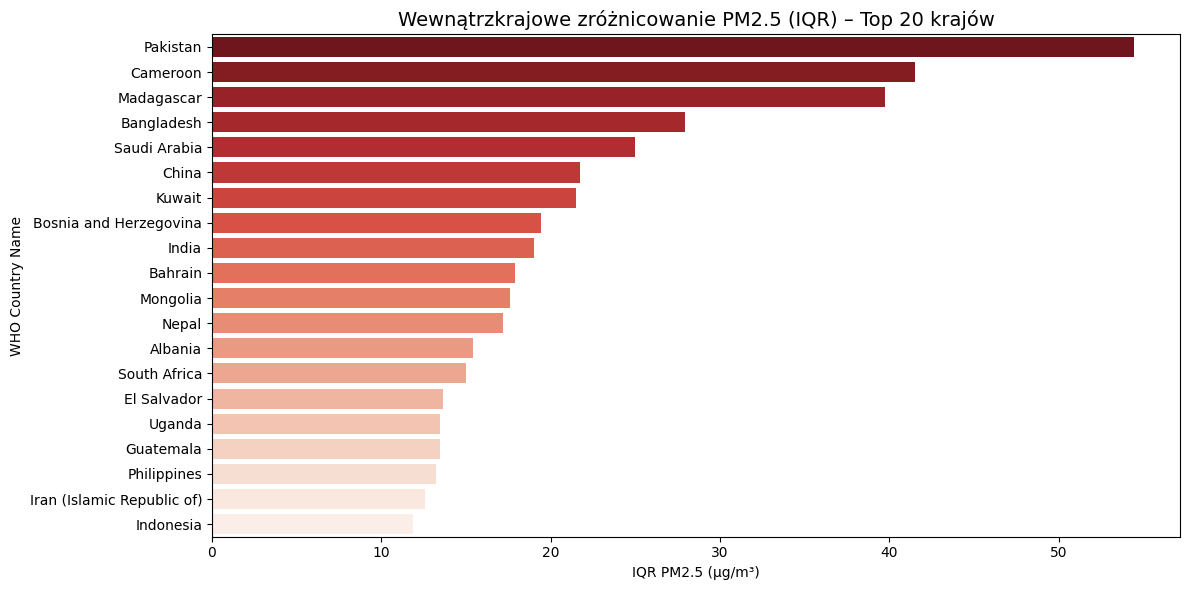

In [24]:
# IQR - rozrzut wartości PM2.5 między miastami w danym kraju.

# Pozwala ocenić w ktorych występują największe różnice między miastami, a tym samym gdzie krajowa średnia jest mało reprezentatywna.
# Z drugierj strony w krajach z najmniejszym rozrzutem wartości są ujednione, w całym kraju wystepują zblizone wartości a średnia dobrze reprezentuje większość miast.

country_iqr = (
    data.groupby('WHO Country Name')['PM2.5 (μg/m3)']
    .apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)
 
plt.figure(figsize=(12, 6))
sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Reds_r')
plt.title('Wewnątrzkrajowe zróżnicowanie PM2.5 (IQR) – Top 20 krajów', fontsize=14)
plt.xlabel('IQR PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

C:\Users\kubek\AppData\Local\Temp\ipykernel_29092\2770491761.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Blues_r')


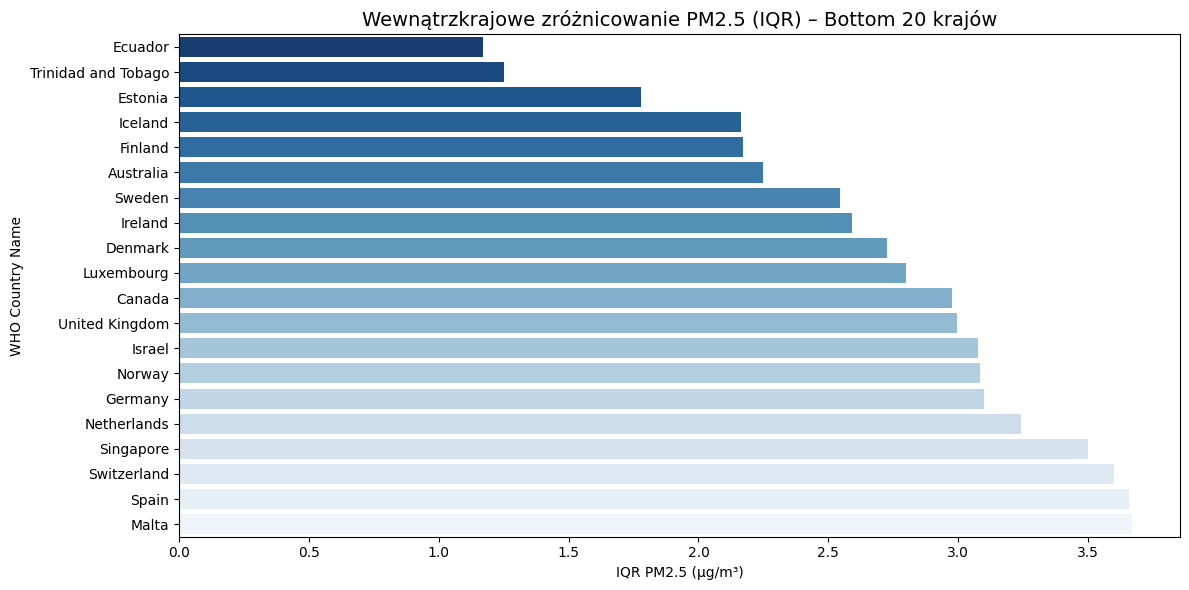

In [25]:
# IQR - bottom 20 krajów dla wartości PM2.5
country_iqr = (
    data.groupby('WHO Country Name')['PM2.5 (μg/m3)']
    .apply(lambda x: x.dropna().quantile(0.75) - x.dropna().quantile(0.25)
           if x.dropna().count() >= 5 else np.nan)
    .dropna()
    .sort_values(ascending=True)
    .head(20)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Blues_r')
plt.title('Wewnątrzkrajowe zróżnicowanie PM2.5 (IQR) – Bottom 20 krajów', fontsize=14)
plt.xlabel('IQR PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

C:\Users\kubek\AppData\Local\Temp\ipykernel_29092\2458128682.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_iqr.values, y=region_iqr.index, palette='Blues_r')


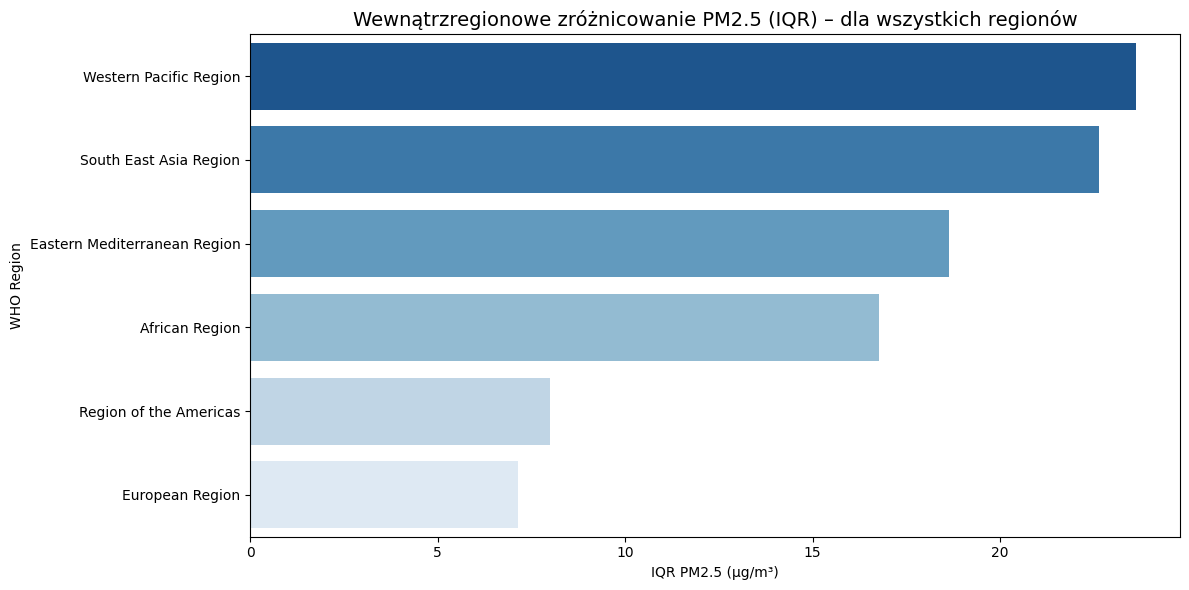

In [26]:
# IQR - rozrzut wartości PM2.5 między miastami w danym regionie
# pokazuje które regiony są bardziej zróżnicowane

region_iqr = (
    data.groupby('WHO Region')['PM2.5 (μg/m3)']
    .apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)
 
plt.figure(figsize=(12, 6))
sns.barplot(x=region_iqr.values, y=region_iqr.index, palette='Blues_r')
plt.title('Wewnątrzregionowe zróżnicowanie PM2.5 (IQR) – dla wszystkich regionów', fontsize=14)
plt.xlabel('IQR PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

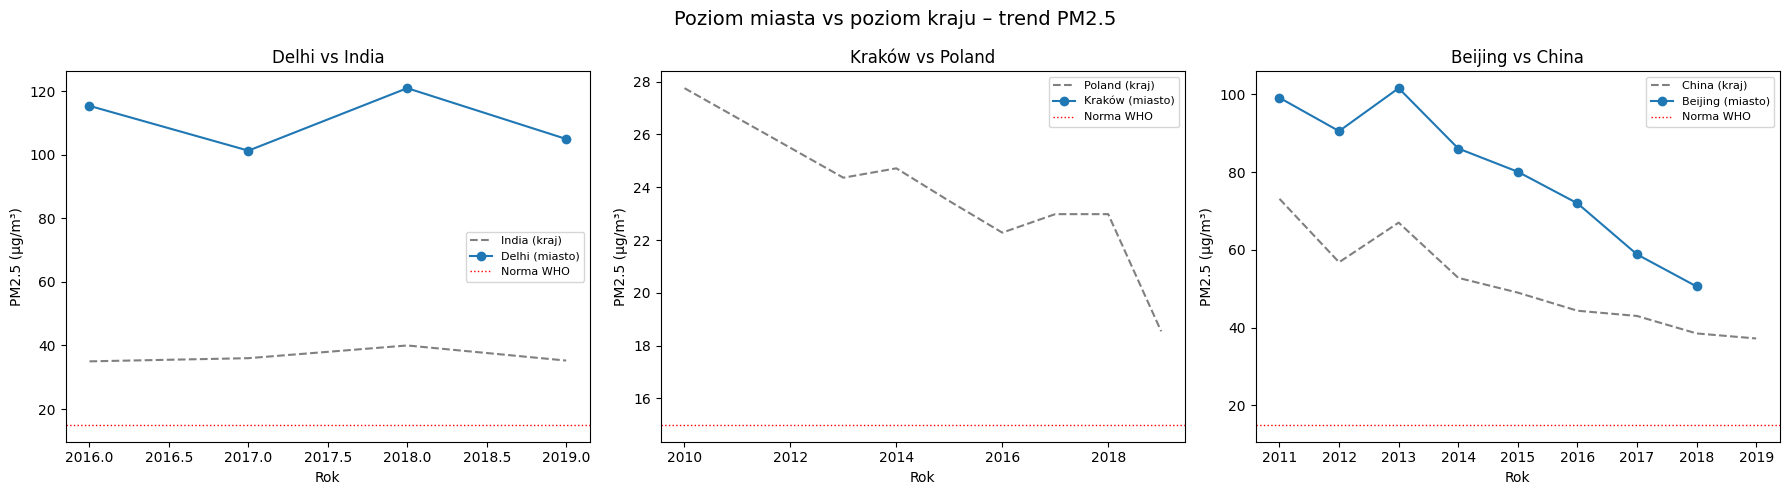

In [27]:
# Porównanie trendu PM2.5 dla wybranych miast z trendem ich kraju.
 
pairs = [('Delhi', 'India'), ('Kraków', 'Poland'), ('Beijing', 'China')]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for ax, (city, country) in zip(axes, pairs):
    city_trend = (
        data[data['City or Locality'] == city]
        .groupby('Measurement Year')['PM2.5 (μg/m3)'].median().reset_index()
    )
    country_trend = (
        data[data['WHO Country Name'] == country]
        .groupby('Measurement Year')['PM2.5 (μg/m3)'].median().reset_index()
    )
    ax.plot(country_trend['Measurement Year'], country_trend['PM2.5 (μg/m3)'],
            linestyle='--', color='gray', label=f'{country} (kraj)')
    ax.plot(city_trend['Measurement Year'], city_trend['PM2.5 (μg/m3)'],
            marker='o', label=f'{city} (miasto)')
    ax.axhline(15, color='red', linestyle=':', linewidth=1, label='Norma WHO')
    ax.set_title(f'{city} vs {country}', fontsize=12)
    ax.set_xlabel('Rok')
    ax.set_ylabel('PM2.5 (μg/m³)')
    ax.legend(fontsize=8)
 
plt.suptitle('Poziom miasta vs poziom kraju – trend PM2.5', fontsize=14)
plt.tight_layout()
plt.show()

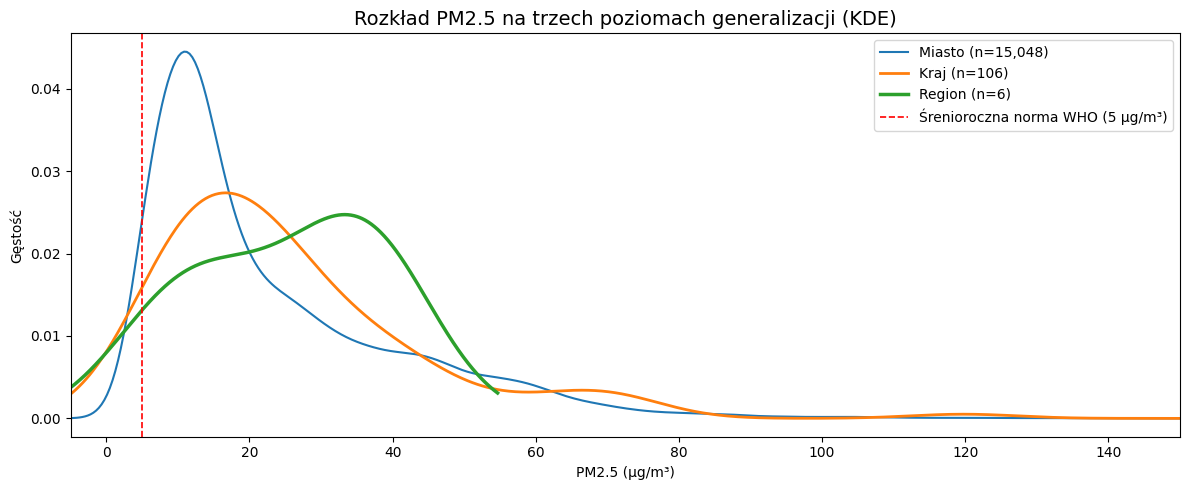

In [28]:
# Agregacja danych pm2.5 na trzech poziomach generalizacji
 
# Agregacja taka pokazuje jak rozkład danych zmienia się w zależności od poziomu generalizacji.
# W przypadku regionów rozkład jest wąski i wycentrowany bez wartości odstających, 
# jednak jest to dla zaledwie 6 regionów, więc cięzko ocenić czy to efekt agregacji czy po prostu małej liczby obserwacji.
# Dla krajów mamy już 100 krajów, więc widać, że rozkład jest szerszy i bardziej skośny niż dla regionów, 
# jednak nieco bardziej uśredniony niż dla miast, gdzie mamy wiele ekstremalnych wartości.
 
pm25_city    = data['PM2.5 (μg/m3)'].dropna()
pm25_country = data.groupby('WHO Country Name')['PM2.5 (μg/m3)'].median().dropna()
pm25_region  = data.groupby('WHO Region')['PM2.5 (μg/m3)'].median().dropna()
 
plt.figure(figsize=(12, 5))
pm25_city.plot.kde(label=f'Miasto (n={len(pm25_city):,})', linewidth=1.5)
pm25_country.plot.kde(label=f'Kraj (n={len(pm25_country)})', linewidth=2)
pm25_region.plot.kde(label=f'Region (n={len(pm25_region)})', linewidth=2.5)
plt.axvline(5, color='red', linestyle='--', linewidth=1.2, label='Śrenioroczna norma WHO (5 μg/m³)')
plt.xlim(-5, 150)
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('Gęstość')
plt.title('Rozkład PM2.5 na trzech poziomach generalizacji (KDE)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

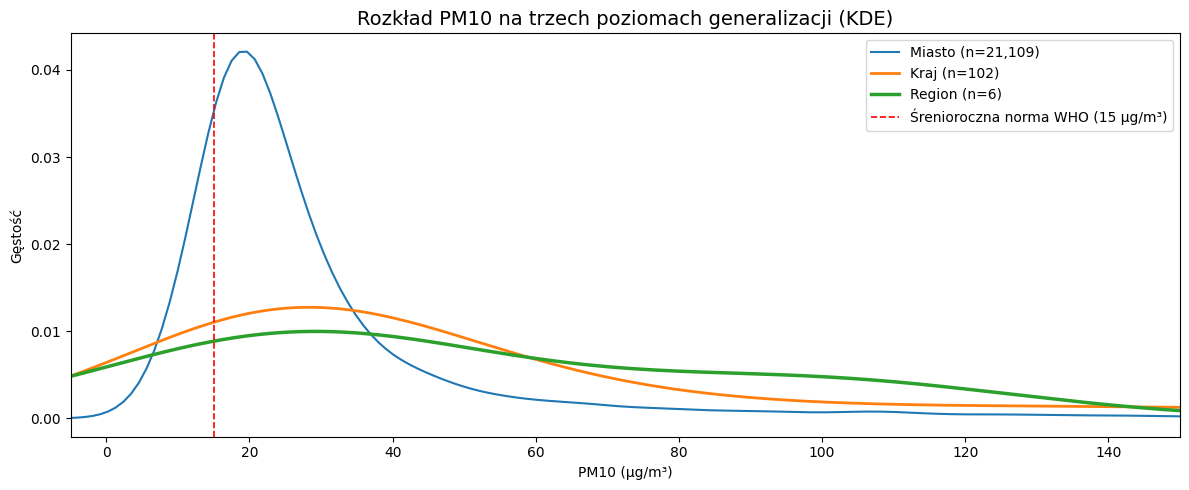

In [29]:
#Agregacja jednak tym razzm dla pm10, pokazuje jeszcze większe różnice między poziomami generalizacji. 
pm10_city    = data['PM10 (μg/m3)'].dropna()
pm10_country = data.groupby('WHO Country Name')['PM10 (μg/m3)'].median().dropna()
pm10_region  = data.groupby('WHO Region')['PM10 (μg/m3)'].median().dropna()

plt.figure(figsize=(12, 5))
pm10_city.plot.kde(label=f'Miasto (n={len(pm10_city):,})', linewidth=1.5)
pm10_country.plot.kde(label=f'Kraj (n={len(pm10_country)})', linewidth=2)
pm10_region.plot.kde(label=f'Region (n={len(pm10_region)})', linewidth=2.5)
plt.axvline(15, color='red', linestyle='--', linewidth=1.2, label='Śrenioroczna norma WHO (15 μg/m³)')
plt.xlim(-5, 150)
plt.xlabel('PM10 (μg/m³)')
plt.ylabel('Gęstość')
plt.title('Rozkład PM10 na trzech poziomach generalizacji (KDE)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

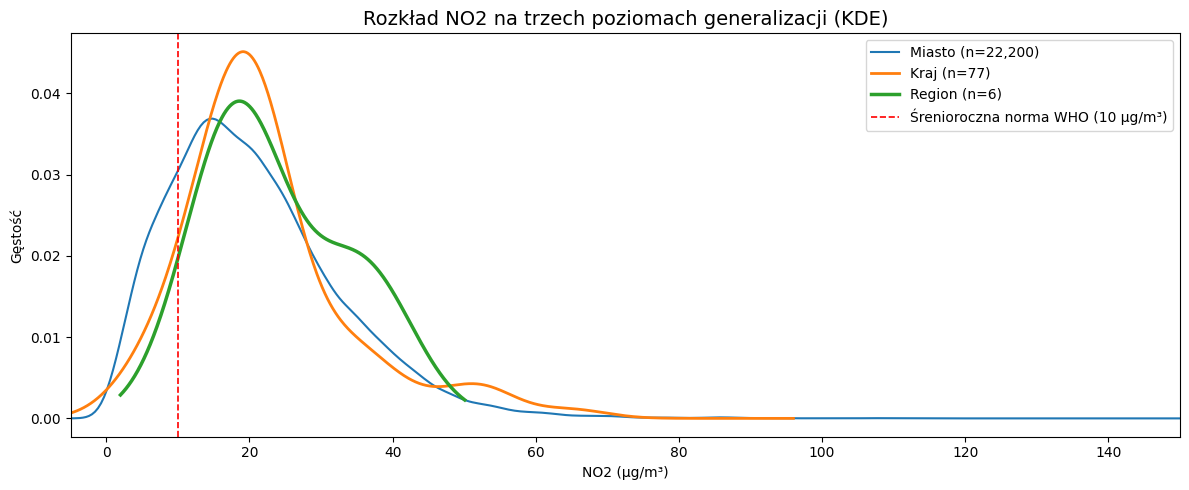

In [30]:
# agregacja dla NO2 
no2_city    = data['NO2 (μg/m3)'].dropna()
no2_country = data.groupby('WHO Country Name')['NO2 (μg/m3)'].median().dropna()
no2_region  = data.groupby('WHO Region')['NO2 (μg/m3)'].median().dropna()

plt.figure(figsize=(12, 5))
no2_city.plot.kde(label=f'Miasto (n={len(no2_city):,})', linewidth=1.5)
no2_country.plot.kde(label=f'Kraj (n={len(no2_country)})', linewidth=2)
no2_region.plot.kde(label=f'Region (n={len(no2_region)})', linewidth=2.5)
plt.axvline(10, color='red', linestyle='--', linewidth=1.2, label='Śrenioroczna norma WHO (10 μg/m³)')
plt.xlim(-5, 150)
plt.xlabel('NO2 (μg/m³)')
plt.ylabel('Gęstość')
plt.title('Rozkład NO2 na trzech poziomach generalizacji (KDE)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

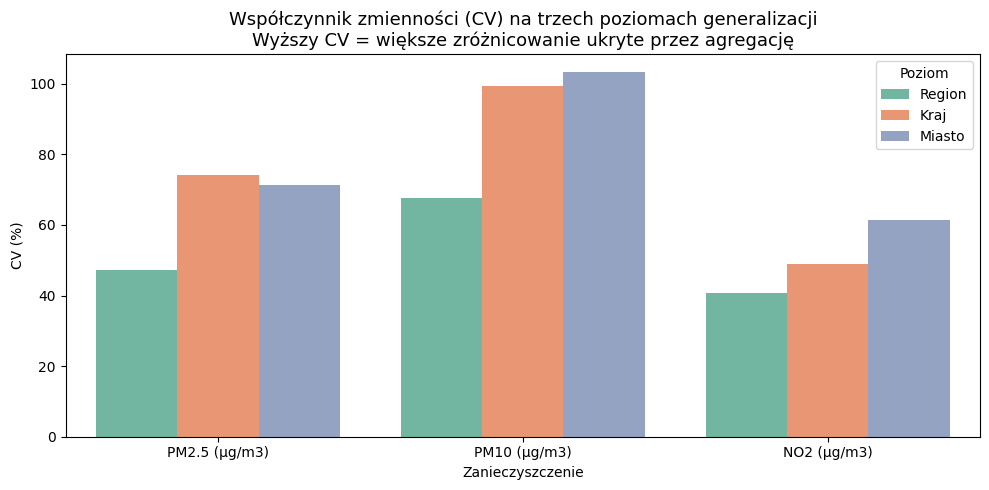

In [31]:
# Współczynnik zmienności (CV) - pokazuje zróżnicowanie danych na trzech poziomach generalizacji

# Im wyższy CV na poziomie miasta vs kraju/regionu, tym bardziej agregacja "wygładza" rzeczywiste zróżnicowanie 
# i ukrywa lokalne zmiany wartości.
# Regiony odpowiadają za ogromne obszary, często o dużej zmienności a uśredniają dane do pojedynczych wartości, tracąc przy tym wiele informacji
# Widać to popraz znacznie niższy poziom CV

cv_data = []
for level, groupby_col in [('Region', 'WHO Region'), ('Kraj', 'WHO Country Name'), ('Miasto', 'City or Locality')]:
    for poll in pollutants:
        vals = data.groupby(groupby_col)[poll].mean().dropna()
        cv = (vals.std() / vals.mean()) * 100
        cv_data.append({'Poziom': level, 'Zanieczyszczenie': poll, 'CV (%)': round(cv, 1)})

cv_df = pd.DataFrame(cv_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_df, x='Zanieczyszczenie', y='CV (%)', hue='Poziom', palette='Set2')
plt.title('Współczynnik zmienności (CV) na trzech poziomach generalizacji\n'
          'Wyższy CV = większe zróżnicowanie ukryte przez agregację', fontsize=13)
plt.ylabel('CV (%)')
plt.tight_layout()
plt.show()

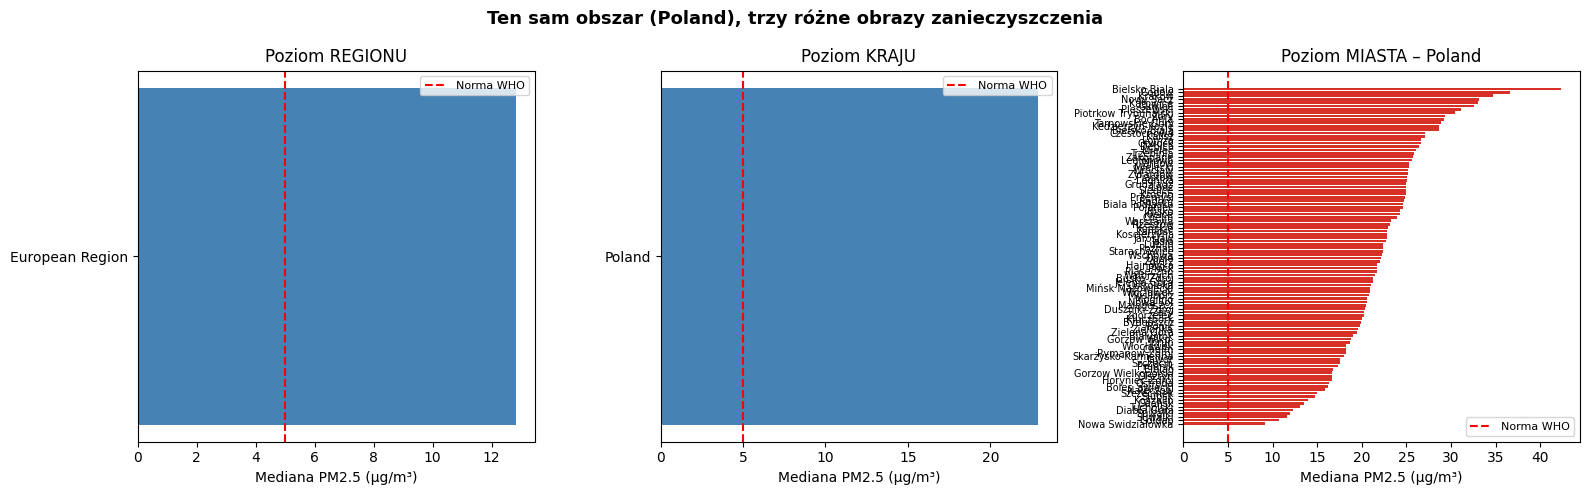

In [32]:
# w Zależności od agregacji dla danego obszaru np  kraju otrzymujemy 3 różne wyniki - dla regionu, kraju i poszczególnych miast.
# Wyniki te jak na przykładzie mogą mieć zupełnie różne wartośći oraz dostarczyć różne wnioski

country_example = 'Poland'
region_example  = 'European Region'

val_region  = data[data['WHO Region'] == region_example]['PM2.5 (μg/m3)'].median()
val_country = data[data['WHO Country Name'] == country_example]['PM2.5 (μg/m3)'].median()
cities_vals = (
    data[data['WHO Country Name'] == country_example]
    .groupby('City or Locality')['PM2.5 (μg/m3)'].median()
    .dropna().sort_values()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# region
axes[0].barh([region_example], [val_region], color='steelblue')
axes[0].axvline(WHO_LIMITS['PM2.5 (μg/m3)'], color='red', linestyle='--', label='Norma WHO')
axes[0].set_title('Poziom REGIONU', fontsize=12)
axes[0].set_xlabel('Mediana PM2.5 (μg/m³)')
axes[0].legend(fontsize=8)

# kraj
axes[1].barh([country_example], [val_country], color='steelblue')
axes[1].axvline(WHO_LIMITS['PM2.5 (μg/m3)'], color='red', linestyle='--', label='Norma WHO')
axes[1].set_title('Poziom KRAJU', fontsize=12)
axes[1].set_xlabel('Mediana PM2.5 (μg/m³)')
axes[1].legend(fontsize=8)

# miasta
axes[2].barh(cities_vals.index, cities_vals.values,
             color=['#d73027' if v > WHO_LIMITS['PM2.5 (μg/m3)'] else '#4575b4' for v in cities_vals.values])
axes[2].axvline(WHO_LIMITS['PM2.5 (μg/m3)'], color='red', linestyle='--', label='Norma WHO')
axes[2].set_title(f'Poziom MIASTA – {country_example}', fontsize=12)
axes[2].set_xlabel('Mediana PM2.5 (μg/m³)')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle(f'Ten sam obszar ({country_example}), trzy różne obrazy zanieczyszczenia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Mapa1 
# Interaktywna mapa  karajów - pokazuje MEDIANĘ zanieczyszczenia dla danego roku
# Dropdowny pozwalają wybrać  jakie zanieczyszczenie i rok jest prezentowany
# Pozawala to obserwacje i analizę rozkłądu zanieczyszczeń na świecie oraz inch zmiany w czasie
# Jednoczesne zastsowanie dropdownów daje też możliwość porównania różnych zanieczyszczeń 

# Po wstępnej analizie widać że Mongolia czy Bangladesz dla PM2.5 (o ile wdanym roku są dane) niemal zawsze mają jedne z najwyższych zanieczyszczeń
# Dla NO2 dominuje Iran przezz cały okres danych
# Dla PM10 niezwykle wysokie wartości ma Egipt (choćdane są tylko dla 3 lat)
# Dzieki możliwosći zmiany daty widoczny jest wyrażny spadek wskaźnika PM2.5 w 2019 w niemal całej Azji 
# podobna sytuacja jest dla PM10 które stopniowo spada od 2015 roku, przede wszystkim w chunach w 2018 roku

# Wartości jednego zanieczyszczenia też niekonieczne mają związek z innymi 
# Np. w Iranie mamy bardzo wysokie NO2, ale stosunkowo niskie PM2.5 i PM10

import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

years = sorted(data['Measurement Year'].dropna().unique().astype(int))
poll_labels = {
    'PM2.5 (μg/m3)': 'PM2.5',
    'PM10 (μg/m3)': 'PM10',
    'NO2 (μg/m3)': 'NO2'
}

def plot_country_map(pollutant, year):
    df_plot = (
        data[data['Measurement Year'] == year]
        .groupby(['ISO3', 'WHO Country Name'])[pollutant]
        .median()
        .reset_index()
        .dropna()
    )

    fig = px.choropleth(
        df_plot,
        locations='ISO3',
        color=pollutant,
        hover_name='WHO Country Name',
        color_continuous_scale='Reds',
        projection='natural earth',
        title=f'Mediana {poll_labels[pollutant]} w krajach – {year}'
    )

    fig.update_layout(
        height=550,
        margin=dict(l=0, r=0, t=60, b=0),
        coloraxis_colorbar_title='μg/m³'
    )

    fig.show()

pollutant_dropdown = widgets.Dropdown(
    options=[(poll_labels[p], p) for p in pollutants],
    value=pollutants[0],
    description='Zanieczyszczenie:'
)

year_dropdown = widgets.Dropdown(
    options=years,
    value=years[0],
    description='Rok:'
)

ui = widgets.HBox([pollutant_dropdown, year_dropdown])

out = widgets.interactive_output(
    plot_country_map,
    {
        'pollutant': pollutant_dropdown,
        'year': year_dropdown
    }
)

display(ui, out)

Output()

In [ ]:
# Mapa 2
# Przypisanie lokalizacji do miast 
# Niestwty nie jest idealne, zdecydowałem się pójsc na kompromis między dokładnością a pokryciem danych
# Mając pewność poprawnego przypisania lokalizacji udało się uzyskać jedynie 55% porycia danych 
# dlatego zdecydowałem sie zwiększyć pokrycie (udało sie do 82% procent) ryzykując,
# że pojawią sie pewne błędy w przypisaniu lokalizacji (miasta o tej samej nazwie w różnych krajach)
# Kilka miast Kuwejtu i Bangladeszu znajduje sie w Eurpie i Ameryce Południowej, kilka miast manualnie poprawiłem

import re
import unicodedata

worldcities = pd.read_csv("worldcities.csv")

def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = re.sub(r"[^a-z0-9\s\-]", "", x)
    x = re.sub(r"\s+", " ", x)
    return x

city_map_data = data.copy()
city_map_data["city_norm"] = city_map_data["City or Locality"].apply(normalize_text)

manual_map = {
    "new york city": "new york",
    "delhi nct": "delhi",
    "kathmandu valley": "kathmandu",
    "greater london": "london",
    "hong kong sar": "hong kong",
    "mexico d f": "mexico city",
    "saint petersburg": "st petersburg"
}

city_map_data["city_norm"] = city_map_data["city_norm"].replace(manual_map)

worldcities["city_norm"] = worldcities["city"].apply(normalize_text)
worldcities["city_ascii_norm"] = worldcities["city_ascii"].apply(normalize_text)

lookup_1 = worldcities[["iso3", "city_norm", "lat", "lng", "population"]].copy()
lookup_2 = worldcities[["iso3", "city_ascii_norm", "lat", "lng", "population"]].copy()
lookup_2 = lookup_2.rename(columns={"city_ascii_norm": "city_norm"})

city_lookup = pd.concat([lookup_1, lookup_2], ignore_index=True)

city_lookup = (
    city_lookup
    .dropna(subset=["iso3", "city_norm", "lat", "lng"])
    .sort_values(["iso3", "city_norm", "population"], ascending=[True, True, False])
    .drop_duplicates(subset=["iso3", "city_norm"])
)

df1 = city_map_data.merge(
    city_lookup[["iso3", "city_norm", "lat", "lng"]],
    left_on=["ISO3", "city_norm"],
    right_on=["iso3", "city_norm"],
    how="left"
)

# --- fallback merge (tylko city) ---
df2 = city_map_data.merge(
    city_lookup[["city_norm", "lat", "lng"]],
    on="city_norm",
    how="left"
)

df1["lat"] = df1["lat"].fillna(df2["lat"])
df1["lng"] = df1["lng"].fillna(df2["lng"])

city_map_data = df1.copy()

matched = city_map_data["lat"].notna().sum()
all_rows = len(city_map_data)

print(f"Liczba wszystkich rekordów: {all_rows}")
print(f"Liczba rekordów z dopasowanymi współrzędnymi: {matched}")
print(f"Odsetek dopasowanych rekordów: {matched / all_rows * 100:.2f}%")

city_map_data = city_map_data[city_map_data["lat"].notna() & city_map_data["lng"].notna()].copy()

city_year_map = (
    city_map_data
    .groupby(
        ["WHO Region", "WHO Country Name", "City or Locality", "Measurement Year", "lat", "lng"],
        as_index=False
    )[pollutants]
    .median()
)
total_cities = data["City or Locality"].nunique()
mapped_cities = city_year_map["City or Locality"].nunique()
coverage_pct = mapped_cities / total_cities * 100

print("\n--- Pokrycie miast ---")
print(f"Liczba wszystkich miast w WHO: {total_cities}")
print(f"Liczba miast na mapie: {mapped_cities}")
print(f"Liczba niedopasowanych miast: {total_cities - mapped_cities}")
print(f"Odsetek pokrycia miast: {coverage_pct:.2f}%")

Liczba wszystkich rekordów: 32191
Liczba rekordów z dopasowanymi współrzędnymi: 26525
Odsetek dopasowanych rekordów: 82.40%

--- Pokrycie miast ---
Liczba wszystkich miast w WHO: 6874
Liczba miast na mapie: 5686
Liczba niedopasowanych miast: 1188
Odsetek pokrycia miast: 82.72%


In [62]:
# Mapa 2
# Mapa punktowa miast - pokazuje stężenie zanieczyszczeń w poszczególnych miastach

# Jest możliwośćfiltrowanai po zanieczyszczeniu, roku i regionie, co pozwala na bardziej szczegółową analizę
# Możemy znajdowac miasta o bardzo wysokim zanieczyszczeniu, które sięwyróżniaja a w danych dla kraju/refionu jest to niewidoczne
# Bez genralizacji możemy znajdować też regiony z innym zanieczyszczeniem wewnątrz poszczególnych krajów (choć często granice państw równiez są widoczne)
# Doskonałym przykładem są Włochy (np PM2.5 2015), gdzie doskonale widoczna jesy Nizina Padańska, która ma znacznie gęstesze pokrycie czujnikami
# oraz odcina sie wyższymi wartościami od południowej części kraju, jednocześnie z północy jest odcięta Alpami od znacznie niższych wartości w reszcie Europy
# Mapa pozwala takze ocenic jak rozmieszczone są dane - widać ogromne różnice pokrycia danych w zależności od regionu cz y kraju
# Wiele krajów jest znacznie mniej reprezentowanych niż inne ponieważ mają np tylko czujnik w jednym mieście (ilość miast z danym dla kraju w komórce niżej)
# Przykładem może być wspomniany wcześniej Egipt, gdzie mamy zaledwie 2 miasta z czujnikami i to one odpowiadająza tak ogromne wartości PM10

# Przy tej mapie jest także możliwośćfiltracji po regionach

from IPython.display import display

poll_labels = {
    'PM2.5 (μg/m3)': 'PM2.5',
    'PM10 (μg/m3)': 'PM10',
    'NO2 (μg/m3)': 'NO2'
}

years_city = sorted(city_year_map["Measurement Year"].dropna().unique().astype(int))
regions_city = ["Wszystkie"] + sorted(city_year_map["WHO Region"].dropna().unique().tolist())

def plot_city_map(pollutant, year, region):
    df_plot = city_year_map[city_year_map["Measurement Year"] == year].copy()

    if region != "Wszystkie":
        df_plot = df_plot[df_plot["WHO Region"] == region].copy()

    df_plot = df_plot.dropna(subset=[pollutant])

    if df_plot.empty:
        print("Brak danych dla wybranej kombinacji filtrów.")
        return

    fig = px.scatter_geo(
        df_plot,
        lat="lat",
        lon="lng",
        color=pollutant,
        hover_name="City or Locality",
        hover_data={
            "WHO Country Name": True,
            "WHO Region": True,
            "Measurement Year": True,
            "PM2.5 (μg/m3)": ":.2f",
            "PM10 (μg/m3)": ":.2f",
            "NO2 (μg/m3)": ":.2f",
            "lat": False,
            "lng": False
        },
        color_continuous_scale="Reds",
        projection="natural earth",
        title=f"Stężenie {poll_labels[pollutant]} w miastach – {year}, region: {region}",
        opacity=0.8
    )

    fig.update_traces(
        marker=dict(
            size=6,
            line=dict(width=0.5, color="white")
        )
    )

    fig.update_layout(
        height=650,
        margin=dict(l=0, r=0, t=60, b=0),
        coloraxis_colorbar_title="μg/m³",
        geo=dict(showcountries=True, countrycolor="black")
    )

    fig.show()


pollutant_dropdown_city = widgets.Dropdown(
    options=[(poll_labels[p], p) for p in pollutants],
    value=pollutants[0],
    description='Zanieczyszczenie:'
)

year_dropdown_city = widgets.Dropdown(
    options=years_city,
    value=years_city[0],
    description='Rok:'
)

region_dropdown_city = widgets.Dropdown(
    options=regions_city,
    value="Wszystkie",
    description='Region:'
)

ui_city = widgets.HBox([pollutant_dropdown_city, year_dropdown_city, region_dropdown_city])

out_city = widgets.interactive_output(
    plot_city_map,
    {
        'pollutant': pollutant_dropdown_city,
        'year': year_dropdown_city,
        'region': region_dropdown_city
    }
)

display(ui_city, out_city)

Output()

In [ ]:
# ── Kontrola pokrycia mapy dla wybranego kraju ───────────────────────────────

import ipywidgets as widgets
from IPython.display import display

countries = sorted(data["WHO Country Name"].dropna().unique().tolist())

def check_country_coverage(country):
    who_cities = (
        data.loc[data["WHO Country Name"] == country, "City or Locality"]
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    mapped_cities = (
        city_map_data.loc[city_map_data["WHO Country Name"] == country, "City or Locality"]
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    total_count = len(who_cities)
    mapped_count = len(mapped_cities)
    missing_count = total_count - mapped_count
    coverage_pct = (mapped_count / total_count * 100) if total_count > 0 else 0

    print(f"Kraj: {country}")
    print(f"Liczba miast w danych WHO: {total_count}")
    print(f"Liczba miast pokazanych na mapie: {mapped_count}")
    print(f"Liczba miast niepokazanych na mapie: {missing_count}")
    print(f"Odsetek pokrycia: {coverage_pct:.2f}%")

    missing_cities = sorted(set(who_cities) - set(mapped_cities))

    if missing_cities:
        print("\nPrzykładowe miasta brakujące na mapie:")
        for city in missing_cities[:20]:
            print("-", city)
        if len(missing_cities) > 20:
            print(f"... oraz {len(missing_cities) - 20} kolejnych.")

country_dropdown = widgets.Dropdown(
    options=countries,
    description="Kraj:",
    layout=widgets.Layout(width="500px")
)

out_country = widgets.interactive_output(
    check_country_coverage,
    {"country": country_dropdown}
)

display(country_dropdown, out_country)

Dropdown(description='Kraj:', layout=Layout(width='500px'), options=('Afghanistan', 'Albania', 'Algeria', 'And…

Output()